In [24]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

print("Imported Successfully")

Imported Successfully


In [25]:
images = []
masks = []

image_path = "data/segmentation/images"
mask_path = "data/segmentation/masks"

image_files = sorted([f for f in os.listdir(image_path) if not f.startswith('.')])
mask_files = sorted([f for f in os.listdir(mask_path) if not f.startswith('.')])

if len(image_files) != len(mask_files):
    print(f" Warning: Mismatch in counts! Images: {len(image_files)}, Masks: {len(mask_files)}")

for img_file, mask_file in zip(image_files, mask_files):

    full_img_path = os.path.join(image_path, img_file)
    full_mask_path = os.path.join(mask_path, mask_file)

    img = cv2.imread(full_img_path)
    mask = cv2.imread(full_mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Skipping: Could not load image file -> {img_file}")
        continue
    if mask is None:
        print(f"Skipping: Could not load mask file -> {mask_file}")
        continue

    img = cv2.resize(img, (128,128))
    mask = cv2.resize(mask, (128,128))

    images.append(img)
    masks.append(mask)

X = np.array(images) / 255.0
y = np.array(masks) / 255.0

y = np.expand_dims(y, axis=-1)

print("Images shape (X):", X.shape)
print("Masks shape (y):", y.shape)

Images shape (X): (20, 128, 128, 3)
Masks shape (y): (20, 128, 128, 1)


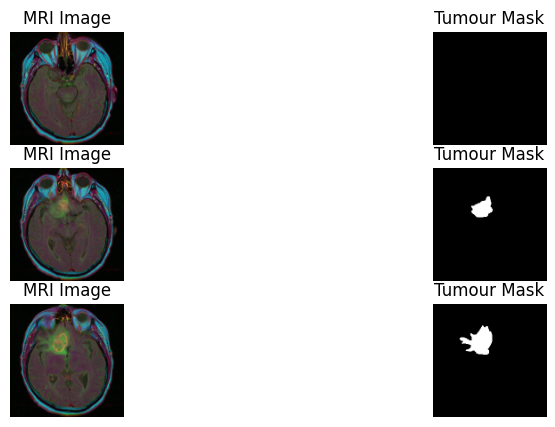

In [26]:
plt.figure(figsize=(10,5))

for i in range(3):

    plt.subplot(3,2,2*i+1)
    plt.imshow(X[i])
    plt.title("MRI Image")
    plt.axis("off")

    plt.subplot(3,2,2*i+2)
    plt.imshow(y[i].squeeze(), cmap='gray')
    plt.title("Tumour Mask")
    plt.axis("off")

plt.show()

In [27]:
inputs = Input((128,128,3))

# Encoder
c1 = Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(32, (3,3), activation='relu', padding='same')(p1)
p2 = MaxPooling2D((2,2))(c2)

# Bottleneck
b1 = Conv2D(64, (3,3), activation='relu', padding='same')(p2)

# Decoder
u1 = UpSampling2D((2,2))(b1)
c3 = Conv2D(32, (3,3), activation='relu', padding='same')(u1)

u2 = UpSampling2D((2,2))(c3)
c4 = Conv2D(16, (3,3), activation='relu', padding='same')(u2)

outputs = Conv2D(1, (1,1), activation='sigmoid')(c4)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,689 (182.38 KB)

 Trainable params: 46,689 (182.38 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.0552 - loss: 0.7095 - val_accuracy: 0.9023 - val_loss: 0.6856
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9127 - loss: 0.6864 - val_accuracy: 0.9715 - val_loss: 0.6716
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9754 - loss: 0.6734 - val_accuracy: 0.9727 - val_loss: 0.6554
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9770 - loss: 0.6586 - val_accuracy: 0.9727 - val_loss: 0.6301
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 997ms/step - accuracy: 0.9770 - loss: 0.6354 - val_accuracy: 0.9727 - val_loss: 0.5939


In [29]:
prediction = model.predict(
    np.expand_dims(X_test[0], axis=0)
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


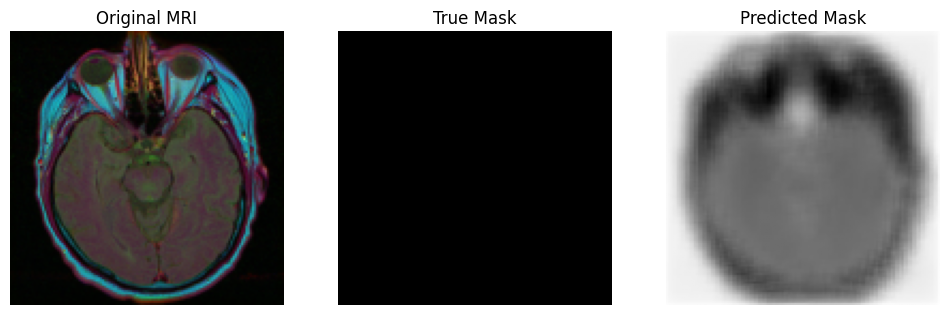

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_test[0])
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(y_test[0].squeeze(), cmap='gray')
plt.title("True Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()